# Predicting Primary Site Using Exceptional Responders Gene Expression Data

Based off work published by [Divate et al. (2022)](https://pmc.ncbi.nlm.nih.gov/articles/PMC8909043/) and [ISB-CGC example notebook](https://github.com/isb-cgc/Community-Notebooks/blob/master/MachineLearning/How_to_predict_cancer_survival_with_BigQueryML.ipynb)

Using Exceptional Responders RNAseq data provided by ISB-CGC (Table ID: isb-cgc-bq.EXC_RESPONDERS_versioned.RNAseq_hg38_gdc_r35)

This dataset is used as practice for larger datasets. Since the dataset is so small, it is difficult to gain any insights from the methods I applied.


### Import Dependencies

In [121]:
# GCP Libraries
from google.cloud import bigquery
from google.colab import auth

# Data Analytics
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from scipy import stats

import torch
from torch import optim, nn, utils, Tensor
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import lightning as L
import torchmetrics

# Visualization
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

### Authenticate

In [63]:
auth.authenticate_user()

### Parameters

In [ ]:
google_project = 'project-name' #CHANGE
rnaseq_table = "isb-cgc-bq.EXC_RESPONDERS_versioned.RNAseq_hg38_gdc_r35"

In [65]:
client = bigquery.Client(google_project)

## Selecting Data Using SQL Query
Using similar methodology as Divate et al. (2022), I will be using protein-coding gene expression data.
Additionally, as done within the work, I will select genes with $\geq 5$ FPKM in at least 50% of the samples within any primary site.

Also, rather than averaging FPKM across aliquots from one sample, I will use each aliquot as a separate sample.

### Query

In [66]:
sql = ("""
-- Select data from protein-coding genes and samples
WITH protein_coding AS (
      SELECT
        primary_site,
        aliquot_barcode,
        fpkm_unstranded,
        Ensembl_gene_id_v
      FROM {rnaseq_table}
      WHERE gene_name IS NOT NULL
        AND gene_type = 'protein_coding'
      ),
-- Select genes that pass threshold of >= 5 FPKM in at least 50% of samples within any primary site
-- Remove samples with PAR_Y as the Y chromosome is not present in all individuals, which may skew the counts
    threshold AS (
      SELECT
        DISTINCT Ensembl_gene_id_v
      FROM (
        SELECT
          primary_site,
          Ensembl_gene_id_v,
          COUNT(Ensembl_gene_id_v) as num_samples,
          COUNT(CASE WHEN fpkm_unstranded >= 5.0 THEN 1 END) as num_fpkm_threshold,
        FROM protein_coding
        WHERE CONTAINS_SUBSTR(Ensembl_gene_id_v, 'par_y') = FALSE
        GROUP BY primary_site, Ensembl_gene_id_v)
      WHERE num_fpkm_threshold / num_samples >= 0.5
    )

-- Select data from genes that pass the threshold
SELECT
  primary_site,
  aliquot_barcode,
  fpkm_unstranded,
  (SPLIT(pc.Ensembl_gene_id_v,  '.'))[safe_ordinal(1)] AS Ensembl_gene_id
FROM protein_coding AS pc
INNER JOIN threshold AS t
  ON pc.Ensembl_gene_id_v = t.Ensembl_gene_id_v
""").format(rnaseq_table=rnaseq_table)

In [67]:
df = client.query(sql).result().to_dataframe()

In [68]:
df[['primary_site', 'aliquot_barcode', 'Ensembl_gene_id']].nunique()

,0
primary_site,20
aliquot_barcode,94
Ensembl_gene_id,12252




* 20 primary sites
* 94 aliquot samples
* 12252 genes

### Pivot DataFrame for FPKM per gene per sample



This is the BQ Query I would use to pivot the table with SQL. However, there is a max of 10,000 columns in BQ, so Pandas DataFrames will be used instead.
```
DECLARE columns STRING;

SET columns = (
  SELECT CONCAT('(', STRING_AGG(FORMAT('%T', Ensembl_gene_id), ','), ')') AS Ensembl_gene_id,
  FROM {threshold}
);

EXECUTE IMMEDIATE FORMAT("""
  SELECT
    *
  FROM  (SELECT aliquot_barcode, primary_site, Ensembl_gene_id, AVG(fpkm_unstranded) as fpkm_unstranded
        FROM {table}
        GROUP BY aliquot_barcode, primary_site, Ensembl_gene_id)
  PIVOT
  (
    AVG(fpkm_unstranded)
    FOR Ensembl_gene_id IN %s
  )
""", columns);
```

In [69]:
data = df.pivot(index=['aliquot_barcode', 'primary_site'], columns='Ensembl_gene_id', values='fpkm_unstranded')

# reset pivot table formatting
data.reset_index(inplace=True)
data.columns.name = None
print(data.info())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Columns: 12254 entries, aliquot_barcode to ENSG00000288631
dtypes: float64(12252), object(2)
memory usage: 8.8+ MB
None


,aliquot_barcode,primary_site,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,...,ENSG00000283297,ENSG00000283787,ENSG00000284609,ENSG00000284680,ENSG00000286106,ENSG00000286190,ENSG00000286522,ENSG00000287080,ENSG00000288607,ENSG00000288631
0,ER-ABCU-TTM1-A-1-0-R-A46C-34,Pancreas,4.4205,0.1918,53.4888,2.4017,3.4226,20.5018,42.3413,11.1924,...,3.7170,0.5287,0.0000,0.0000,1.1855,0.9765,9.9243,9.8523,0.0000,0.0000
1,ER-ABCU-TTP1-A-1-0-R-A46C-34,Pancreas,1.4814,0.0000,78.0745,2.8302,6.1040,13.7648,49.0092,7.8990,...,9.8712,2.3100,0.0000,0.0000,1.0177,1.9814,47.7949,32.0399,0.0000,0.0000
2,ER-ABDN-TTP1-A-2-0-R-A46G-34,Stomach,9.7158,0.0795,153.3185,3.3497,8.2385,0.6796,9.5434,14.4616,...,1.7234,0.1474,0.0000,0.0000,0.1900,0.4065,21.9857,27.3152,2.6870,5.2740
3,ER-ABDX-NT1-A-1-0-R-A46K-34,Pancreas,4.9400,0.2589,45.1744,1.5151,1.8635,1.0101,24.0499,8.3228,...,3.1015,0.2826,0.2382,0.0426,0.6878,0.3147,4.7942,3.9309,0.0000,0.9039
4,ER-ABDX-TTP1-A-2-0-R-A46K-34,Pancreas,5.6414,0.4016,81.2015,2.0871,5.2594,4.6450,79.2386,11.3155,...,3.1517,0.7090,0.0091,0.0000,4.2864,0.8168,10.6341,12.1976,0.9754,0.5539


## Pre-Process and Transform Data for Machine Learning Input


In [80]:
y = data['primary_site']
X = data.select_dtypes(include="number")

### Log Transform FPKM Values
As done in Divate et al. (2022), I will log10 transform the values before input into the machine learning model.

In [71]:
X_log = np.log10(X + 1)

Text(0.5, 1.0, 'Log10(x+1) Transformed Data')

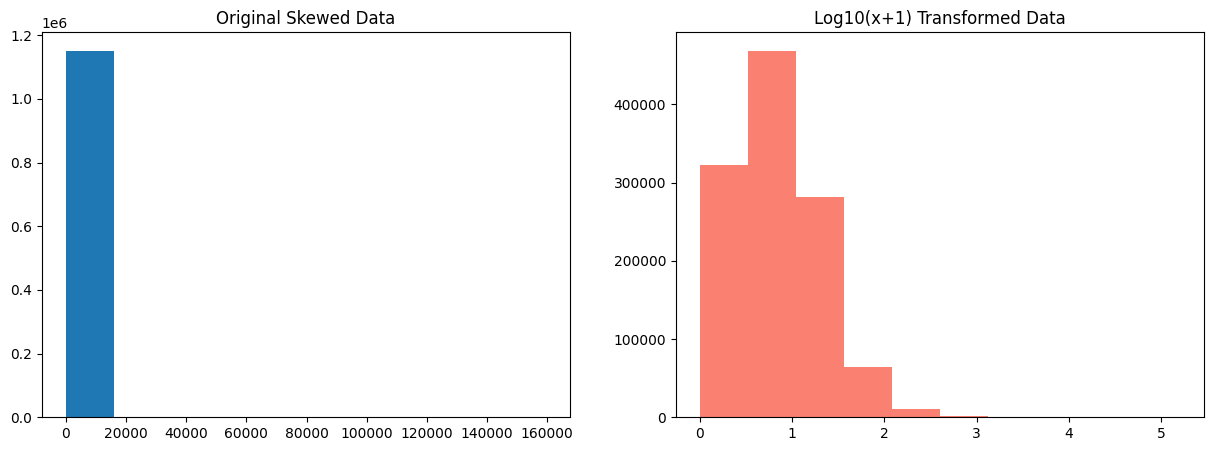

In [72]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.hist(X.values.ravel(), bins=10)
plt.title("Original Skewed Data")

plt.subplot(1, 2, 2)
plt.hist(X_log.values.ravel(), bins=10, color='Salmon')
plt.title("Log10(x+1) Transformed Data")


### Label encode primary sites

In [81]:
le = LabelEncoder()
y = pd.DataFrame(le.fit_transform(y), columns=['primary_site'])

In [299]:
C = y['primary_site'].nunique()  # Number of labels
# plt.hist(y.values.ravel(), bins=C)

### T-SNE Plot to Observe Clustering

In [300]:
tsne = pd.DataFrame(TSNE(n_components=2, random_state=123).fit_transform(X), columns=['Dim1', 'Dim2'])
tsne_log = pd.DataFrame(TSNE(n_components=2, random_state=123).fit_transform(X_log), columns=['Dim1', 'Dim2'])

In [301]:
# define the colormap
cmap = plt.cm.jet
# extract all colors from the .jet map
cmaplist = [cmap(i) for i in range(cmap.N)]
# create the new map
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, cmap.N)

# define the bins and normalize
bounds = np.linspace(0, C, C+1)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

Text(0.5, 1.0, 'Log10(x+1) Transformed Data')

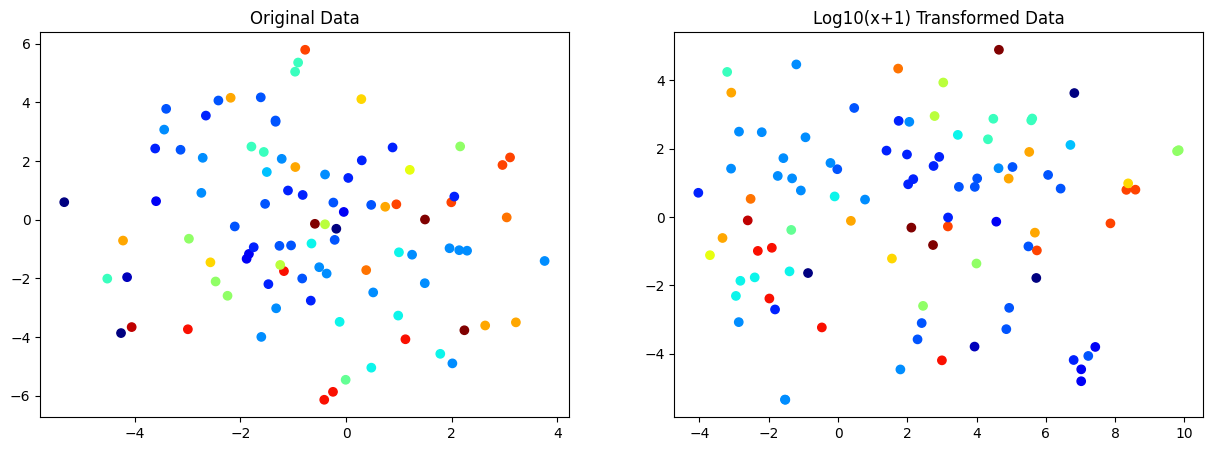

In [302]:
fig = plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.scatter(x=tsne['Dim1'], y=tsne['Dim2'], c=y['primary_site'], cmap=cmap, norm=norm)
plt.title("Original Data")

plt.subplot(1, 2, 2)
plt.scatter(x=tsne_log['Dim1'], y=tsne_log['Dim2'], c=y['primary_site'], cmap=cmap, norm=norm)
plt.title("Log10(x+1) Transformed Data")


### Split data into different sets

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

In [82]:
# 70% training, 10% validation, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_log, y, test_size=0.2, random_state=123)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=123)

In [100]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.flatten())
y_val_tensor = torch.tensor(y_val.values.flatten())
y_test_tensor = torch.tensor(y_test.values.flatten())

In [102]:
train_data = TensorDataset(X_train_tensor, y_train_tensor)
val_data = TensorDataset(X_val_tensor, y_val_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

## Machine Learning Model


The model used is similar to the model discussed in Divate et al. (2022) with implementation in PyTorch and some changes to layers.

In [215]:
C = y['primary_site'].nunique()  # Number of labels
input_size = X.shape[1]

class NeuralNetwork(L.LightningModule):
    def __init__(self, learning_rate):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, C)
        )

        self.learning_rate = learning_rate
        self.train_acc = torchmetrics.classification.Accuracy(task="multiclass", num_classes=C)
        self.valid_acc = torchmetrics.classification.Accuracy(task="multiclass", num_classes=C)

    def forward(self, batch):
        inputs, _ = batch
        return self.model(inputs)

    def training_step(self, batch, batch_idx):
        inputs, target = batch
        output = self.model(inputs)
        loss = nn.functional.cross_entropy(output, target)
        self.train_acc(output, target)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_accuracy", self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, target = batch
        output = self.model(inputs)
        loss = nn.functional.cross_entropy(output, target)
        self.valid_acc(output, target)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_accuracy", self.valid_acc, on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        inputs, target = batch
        output = self.model(inputs)
        loss = nn.functional.cross_entropy(output, target)
        self.valid_acc(output, target)
        self.log("test_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_accuracy", self.valid_acc, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer


### Custom Logger
For displaying loss curves

In [197]:
import collections
from lightning.pytorch.loggers.logger import Logger, rank_zero_experiment
from lightning.pytorch.utilities import rank_zero_only

class CustomLogger(Logger):
    def __init__(self):
      super().__init__()

      self.history = collections.defaultdict(list)

    @property
    def name(self):
      return "Logger"

    @property
    def version(self):
      return "0.1"

    @rank_zero_only
    def log_hyperparams(self, params):
      # params is an argparse.Namespace
      pass

    @rank_zero_only
    def log_metrics(self, metrics, step):
      for metric_name, metric_value in metrics.items():
        if metric_name != 'epoch':
            self.history[metric_name].append(metric_value)
        else:
            if (not len(self.history['epoch']) or
                not self.history['epoch'][-1] == metric_value) :
                self.history['epoch'].append(metric_value)
            else:
                pass
      return

### Set training parameters

In [205]:
learning_rate = 1e-5
batch_size = 1
epochs = 50
patience = 10
delta = 0.00
val_epochs = 1

### Load data and model

In [216]:
model = NeuralNetwork(learning_rate)
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

### Set up training

In [207]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import ModelCheckpoint
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=delta, patience=patience, mode="min")
checkpoint_callback = ModelCheckpoint(monitor='val_loss', dirpath='checkpoints/',
                                          filename='{epoch}-{val_loss:.2f}')
logger = CustomLogger()

trainer = L.Trainer(max_epochs=epochs,
                    check_val_every_n_epoch=val_epochs,
                    callbacks=[early_stop_callback, checkpoint_callback],
                    logger=logger
                    )

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## Training Loop

In [208]:
trainer.fit(model, train_dataloader, val_dataloader)

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ Sequential         │  6.5 M │ train │     0 │
│ 1 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ valid_acc │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 6.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.5 M                                                                                                
Total estimated model params size (MB): 25                                                                         
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


### Plotting Loss and Accuracy Over Training

In [143]:
# For default logging:
# %reload_ext tensorboard
# %tensorboard --logdir=lightning_logs/

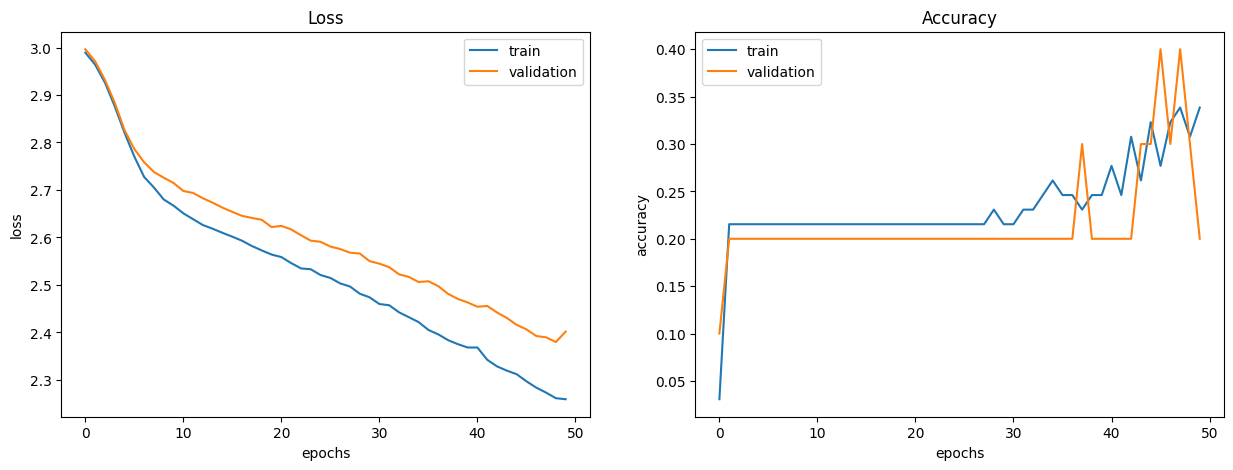

In [209]:
x_axis = logger.history['epoch']
train_loss = logger.history['train_loss']
val_loss = logger.history['val_loss']
train_acc = logger.history['train_accuracy']
val_acc = logger.history['val_accuracy']

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(x_axis, train_loss, label='train')
plt.plot(x_axis, val_loss, label='validation')
plt.legend()
plt.ylabel("loss")
plt.xlabel("epochs")
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(x_axis, train_acc, label='train')
plt.plot(x_axis, val_acc, label='validation')
plt.legend()
plt.ylabel("accuracy")
plt.xlabel("epochs")
plt.title("Accuracy")
plt.show()

## Testing

In [210]:
# checkpoint_callback.best_model_path
# /content/Logger/0.1/checkpoints/epoch=162-step=10595.ckpt
trainer.test(dataloaders=test_dataloader, ckpt_path='best')

INFO: Restoring states from the checkpoint path at /content/checkpoints/epoch=48-val_loss=2.38.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/epoch=48-val_loss=2.38.ckpt
INFO: Loaded model weights from the checkpoint at /content/checkpoints/epoch=48-val_loss=2.38.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/epoch=48-val_loss=2.38.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.10526315867900848    │
│         test_loss         │     3.028773546218872     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 3.028773546218872, 'test_accuracy': 0.10526315867900848}]

### Other Evaluations

In [282]:
# full dataset
X_tensor = torch.tensor(X_log.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values.flatten())
full_data = TensorDataset(X_tensor, y_tensor)
full_dataloader = DataLoader(full_data, batch_size=batch_size)

logits = trainer.predict(model, full_dataloader, ckpt_path='best')

INFO: Restoring states from the checkpoint path at /content/checkpoints/epoch=48-val_loss=2.38.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/epoch=48-val_loss=2.38.ckpt
INFO: Loaded model weights from the checkpoint at /content/checkpoints/epoch=48-val_loss=2.38.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/epoch=48-val_loss=2.38.ckpt


Output()

In [285]:
y_true = y_tensor
y_pred = torch.argmax(torch.cat(logits), axis=1)
target_names = le.classes_

In [289]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_true, y_pred, labels=le.transform(target_names), target_names=target_names))

                                                 precision    recall  f1-score   support

                            Anus and anal canal       0.00      0.00      0.00         3
                                        Bladder       0.00      0.00      0.00         1
                                          Brain       0.00      0.00      0.00         4
                                         Breast       0.23      0.73      0.35        11
                              Bronchus and lung       0.42      0.36      0.38        14
                                          Colon       0.37      1.00      0.54        17
Connective, subcutaneous and other soft tissues       0.00      0.00      0.00         1
                                      Esophagus       0.00      0.00      0.00         6
                                         Kidney       0.00      0.00      0.00         5
         Other and ill-defined digestive organs       0.00      0.00      0.00         1
                    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [290]:
confusion_matrix = confusion_matrix(y_true, y_pred, labels=le.transform(target_names))
print(confusion_matrix)

[[ 0  0  0  1  0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  3  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  8  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  5  5  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  3  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  1  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  0  1  0  0  0  0  0  0  0  0  0  0  0  0

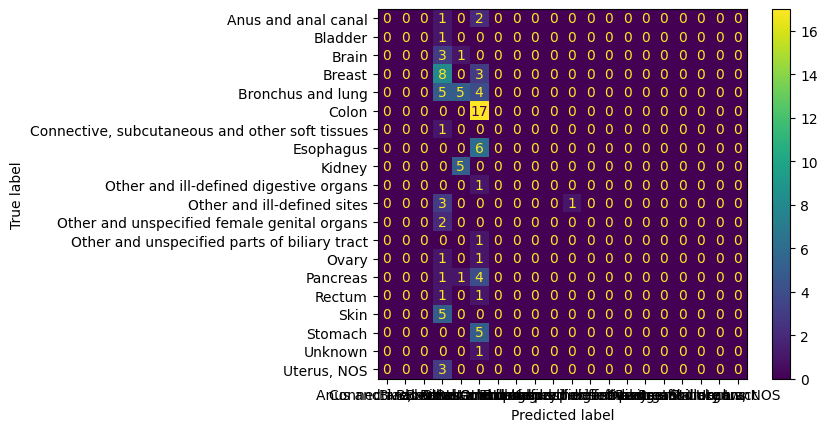

In [292]:
disp = ConfusionMatrixDisplay(confusion_matrix, display_labels=target_names)
disp.plot()